# Markers for clusters before grouping to cell types

In [1]:
here::i_am("revisions/03_cellannotation/01_cellAnnnotation.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ArchR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# outdir
args$outdir = file.path(io$basedir, 'results/revisions/03_cellannotation/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
meta = fread(args$metadata) %>% .[genotype == 'WT']

In [52]:
# sorry to whomever reads this for how convoluted this is

# Calculate proportions label transfer per final annotation
to.plot = meta %>% .[genotype == 'WT'] %>%
    .[, Ntot := .N, by = 'celltype_v2'] %>% # total cell numbers per final annotation
    .[, prop := .N/Ntot, by = c('celltype_v2', 'celltype.mapped_mnn')] %>%  # Proportions per label transfer cell type
    unique(by = c('celltype_v2', 'celltype.mapped_mnn')) %>% # keep only unique combinations 
    .[, max_prop := max(prop), by = 'celltype.mapped_mnn'] %>% # calculate max proportion for filtering 
    .[, celltype_plot := factor(ifelse(max_prop < 0.05, 'Other', celltype.mapped_mnn), levels = c(names(opts$celltype.colors), 'Other'))] %>% # rename rare label transfer cell types to 'other', also set levels
    .[, prop := sum(prop), by = c('celltype_v2', 'celltype_plot')] %>% # calculate the sum of proportions for the newly generate 'other' label transfer cell types
    .[, celltype_v2_plot := factor(gsub('_', ' ', celltype_v2), levels = c('PGC', gsub('_', ' ', opts$celltype_levels2)))] %>% # rename our own annotations
    unique(by = c('celltype_v2_plot', 'celltype_plot'))  # keep only unique combinations, after having set label transfer cell types as 'Other' 



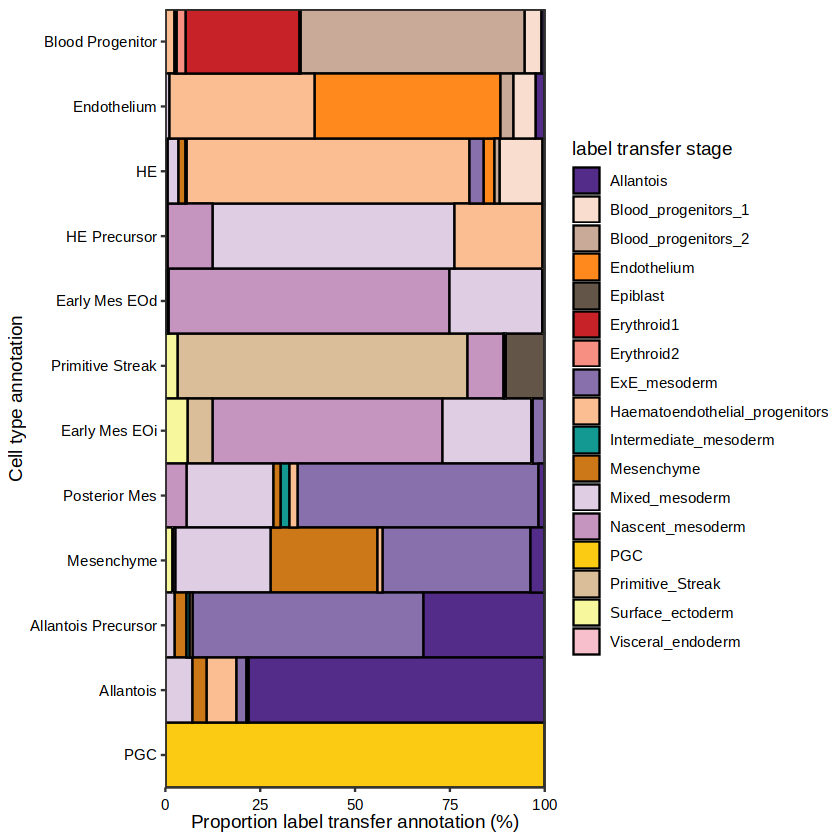

In [53]:
p1 = ggplot(to.plot, aes(celltype_v2_plot, prop * 100, fill = celltype.mapped_mnn)) + 
    geom_bar(stat = 'identity', position = 'stack', color = 'black',  linewidth = 0.5, width = 1) + 
    scale_fill_manual(values = c(opts$celltype.colors, 'Other' = 'grey80'), name = 'label transfer stage') + 
    coord_flip() + 
    scale_y_continuous(expand = c(0,0)) + 
    scale_x_discrete(expand = c(0,0)) + 
    ylab('Proportion label transfer annotation (%)') + 
    xlab('Cell type annotation') + 
    theme_bw() + 
    theme(axis.text = element_text(color = 'black'),
          axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0))
p1 

In [54]:
ggsave(file.path(args$outdir, 'labeltransfer.pdf'), 
       plot = p1,
       width = 120, 
       height = 60, 
       units = "mm")

In [55]:
meta_atlas = fread(io$rna.atlas.metadata)

In [66]:
to.plot = meta %>% copy() %>%
    cbind(., meta_atlas[match(.$closest.cell_mnn, meta_atlas$cell)] %>% .[,.(umapX, umapY)])

In [67]:
set.seed(1234)
p1 = ggplot(to.plot[sample(nrow(to.plot))], aes(umapX, umapY, color = celltype_v2)) + 
    ggrastr::rasterise(geom_point(data = meta_atlas, 
               color='black', size = -0.05), dpi = 600) + 
    ggrastr::rasterise(geom_point(data = meta_atlas, 
               color='grey90', size = -0.15), dpi = 600) + 
    geom_point(size=-0.2, position = position_jitter(width = 0.05, height = 0.05)) + 
    scale_color_manual(values = opts$celltype_v2.colors) + 
    coord_fixed(ratio = 0.75) + 
    theme_void() + 
    theme(legend.position='right',
          strip.background=element_blank(),
          strip.text=element_text(size=8))
# p1 

In [68]:
ggsave(file.path(args$outdir, 'umap_projection.pdf'), 
       plot = p1 + theme(legend.position = 'none'), 
       width = 80, height = 90, units = "mm")

In [69]:
celltype_keep = meta %>% .[genotype == 'WT'] %>%
    .[, Ntot := .N, by = 'celltype_v2'] %>% # total cell numbers per final annotation
    .[, prop := .N/Ntot, by = c('celltype_v2', 'celltype.mapped_mnn')] %>%  # Proportions per label transfer cell type
    unique(by = c('celltype_v2', 'celltype.mapped_mnn')) %>% # keep only unique combinations 
    .[, max_prop := max(prop), by = 'celltype.mapped_mnn'] %>% # calculate max proportion for filtering 
    .[, celltype_keep := ifelse(max_prop < 0.05, 'Other', celltype.mapped_mnn)] %>% 
    .$celltype_keep %>% unique()

In [70]:
to.plot = to.plot %>% 
    .[, celltype_mapped := ifelse(celltype.mapped_mnn %in% celltype_keep, celltype.mapped_mnn, 'Other')]

In [78]:
set.seed(1234)
p1 = ggplot(to.plot[sample(nrow(to.plot))], aes(umapX, umapY, color = celltype_mapped)) + 
    ggrastr::rasterise(geom_point(data = meta_atlas, 
               color='black', size = -0.05), dpi = 600) + 
    ggrastr::rasterise(geom_point(data = meta_atlas, 
               color='grey90', size = -0.15), dpi = 600) + 
    geom_point(size=-0.2, position = position_jitter(width = 0.05, height = 0.05)) + 
    scale_color_manual(values = c(opts$celltype.colors, 'Other' = 'grey80')) + 
    coord_fixed(ratio = 0.75) + 
    theme_void() + 
    theme(legend.position='right',
          strip.background=element_blank(),
          strip.text=element_text(size=8))
# p1 

In [79]:
ggsave(file.path(args$outdir, 'umap_projection_atlaslabels.pdf'), 
       plot = p1 + theme(legend.position = 'none'), 
       width = 60, height = 60, units = "mm")

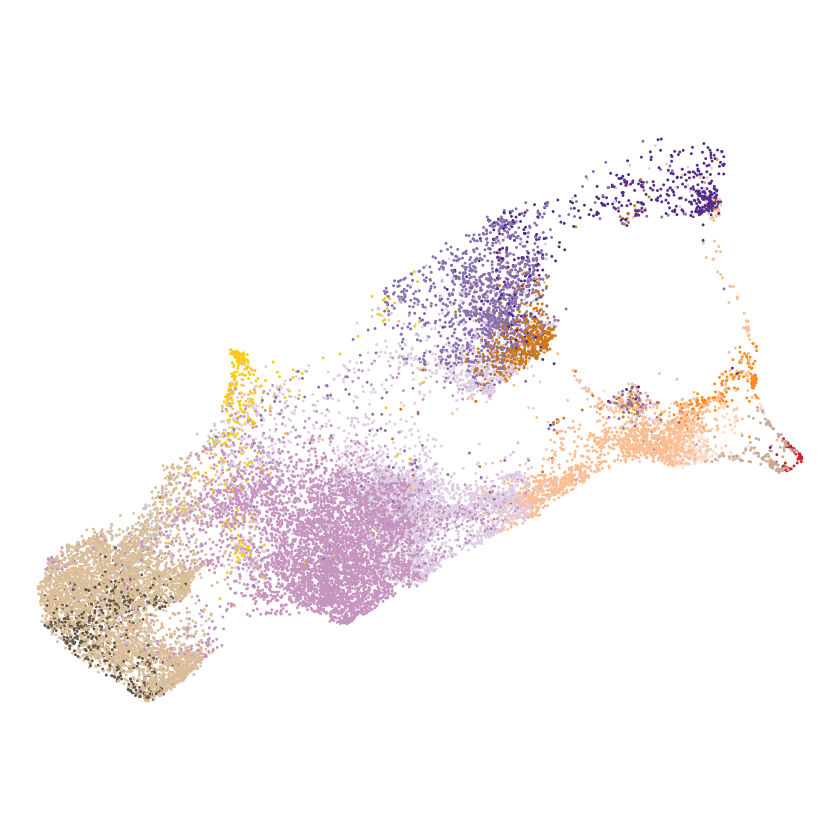

In [85]:
p1 = ggplot(to.plot[sample(nrow(to.plot))], aes(UMAP1, UMAP2, color = celltype_mapped)) + 
    geom_point(size=-0.2) + 
    scale_color_manual(values = c(opts$celltype.colors, 'Other' = 'grey80')) + 
    coord_fixed(ratio = 1) + 
    theme_void() + 
    theme(legend.position='none',
          strip.background=element_blank(),
          strip.text=element_text(size=8))
p1

In [86]:
ggsave(file.path(args$outdir, 'umap_atlaslabels.pdf'), 
       plot = p1 + theme(legend.position = 'none'), 
       width = 30, height = 30, units = "mm")

In [24]:
# sorry to whomever reads this for how convoluted this is

# Calculate proportions label transfer per final annotation
to.plot = meta %>% .[genotype == 'WT'] %>%
    .[, Ntot := .N, by = 'celltype_v2'] %>% # total cell numbers per final annotation
    .[, prop := .N/Ntot, by = c('celltype_v2', 'stage.mapped_mnn')] %>%  # Proportions per label transfer cell type
    unique(by = c('celltype_v2', 'stage.mapped_mnn')) %>% # keep only unique combinations 
    .[, max_prop := max(prop), by = 'stage.mapped_mnn'] %>% # calculate max proportion for filtering 
    unique(by = c('celltype_v2', 'stage.mapped_mnn')) %>% # keep only unique combinations, after having set label transfer cell types as 'Other' 
    .[, celltype_v2_plot := factor(gsub('_', ' ', celltype_v2), levels = c('PGC', gsub('_', ' ', opts$celltype_levels2)))] # rename our own annotations



In [26]:
table(meta$day)


  D3 D3.5   D4 D4.5   D5 
4461 9834 4261  445  739 

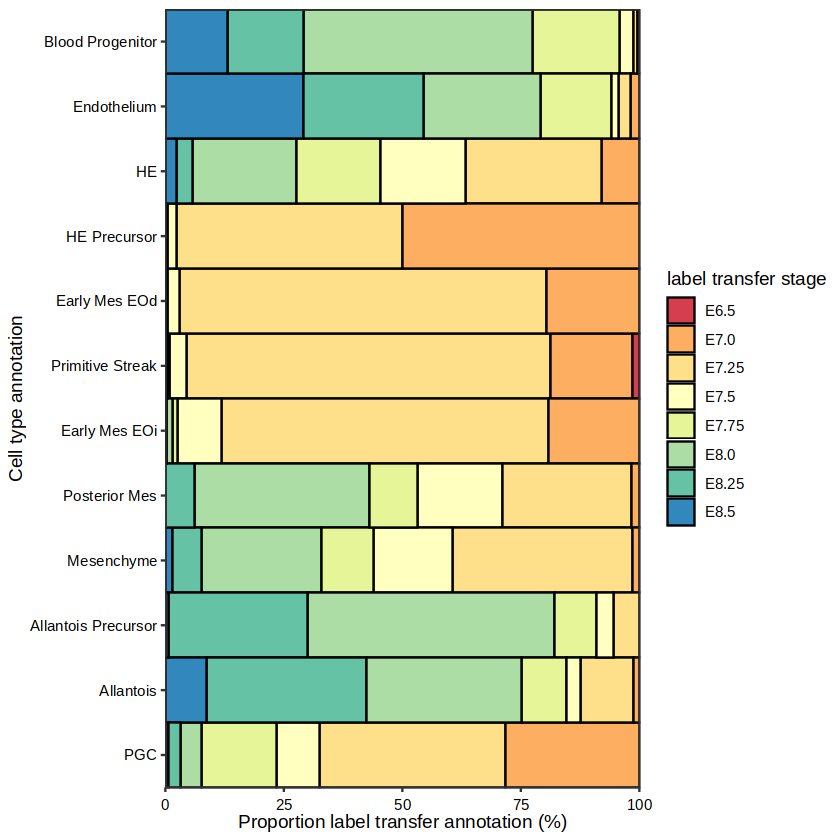

In [25]:
p1 = ggplot(to.plot, aes(celltype_v2_plot, prop * 100, fill = stage.mapped_mnn)) + 
    geom_bar(stat = 'identity', position = 'stack', color = 'black',  linewidth = 0.5, width = 1) + 
    scale_fill_manual(values = c(opts$stage.colors.original, 'Other' = 'grey80'), name = 'label transfer stage') + 
    coord_flip() + 
    scale_y_continuous(expand = c(0,0)) + 
    scale_x_discrete(expand = c(0,0)) + 
    ylab('Proportion label transfer annotation (%)') + 
    xlab('Cell type annotation') + 
    theme_bw() + 
    theme(axis.text = element_text(color = 'black'),
          axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0))
p1 

In [27]:
# sorry to whomever reads this for how convoluted this is

# Calculate proportions label transfer per final annotation
to.plot = meta %>% .[genotype == 'WT'] %>%
    .[, Ntot := .N, by = 'day'] %>% # total cell numbers per final annotation
    .[, prop := .N/Ntot, by = c('day', 'stage.mapped_mnn')] %>%  # Proportions per label transfer cell type
    unique(by = c('day', 'stage.mapped_mnn')) %>% # keep only unique combinations 
    .[, max_prop := max(prop), by = 'stage.mapped_mnn'] %>% # calculate max proportion for filtering 
    unique(by = c('day', 'stage.mapped_mnn')) # keep only unique combinations, after having set label transfer cell types as 'Other' 


In [28]:
table(meta$day)


  D3 D3.5   D4 D4.5   D5 
4461 9834 4261  445  739 

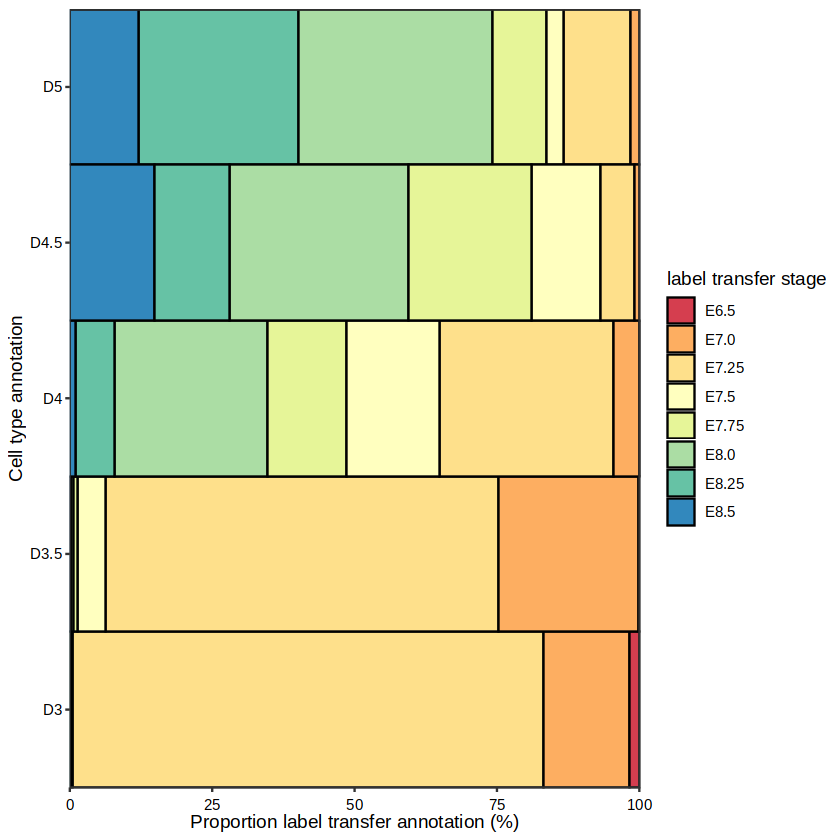

In [29]:
p1 = ggplot(to.plot, aes(day, prop * 100, fill = stage.mapped_mnn)) + 
    geom_bar(stat = 'identity', position = 'stack', color = 'black',  linewidth = 0.5, width = 1) + 
    scale_fill_manual(values = c(opts$stage.colors.original, 'Other' = 'grey80'), name = 'label transfer stage') + 
    coord_flip() + 
    scale_y_continuous(expand = c(0,0)) + 
    scale_x_discrete(expand = c(0,0)) + 
    ylab('Proportion label transfer annotation (%)') + 
    xlab('Cell type annotation') + 
    theme_bw() + 
    theme(axis.text = element_text(color = 'black'),
          axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0))
p1 

## Cluster marker gene expression levels

In [4]:
args$markersdir = file.path(io$basedir, 'results/rna_atac/clustering/')
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

In [5]:
opts$clusters2celltypes = c(
    '0' = 'Early_Mes_EOd',
    '1' = 'Early_Mes_EOd',
    '2' = 'Primitive_Streak',
    '3' = 'HE',
    '4' = 'Posterior_Mes',
    '5' = 'Mesenchyme',
    '6' = 'Early_Mes_EOi',
    '7' = 'Primitive_Streak',
    '8' = 'Early_Mes_EOi',
    '9' = 'Early_Mes_EOi',
    '10' = 'Allantois',
    '11' = 'Primitive_Streak',
    '12' = 'Allantois_Precursor',
    '13' = 'Posterior_Mes',
    '14' = 'HE_Precursor',
    '15' = 'Endothelium',
    '16' = 'Primitive_Streak',
    '17' = 'Blood_Progenitor'    
)

In [6]:
# rna cluster markers
meta = fread(args$metadata) %>% .[genotype == 'WT'] #%>%
   # .[, clusters := ifelse(celltype.mapped_mnn == 'PGC', 'PGC', mofa_cluster)]

# Load precalculated markers
#markers = fread(sprintf('%s/markers_RNA.txt.gz', args$markersdir))

# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

# Convert to Seurat
seurat = as.Seurat(rna.sce)

In [7]:
Idents(seurat) = seurat@meta.data$mofa_cluster

In [12]:
# Marker detection
markers <- FindAllMarkers(seurat, 
                          only.pos = TRUE, 
                          min.pct = 0.25,
                          logfc.threshold = 0.5, 
                          verbose = F)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


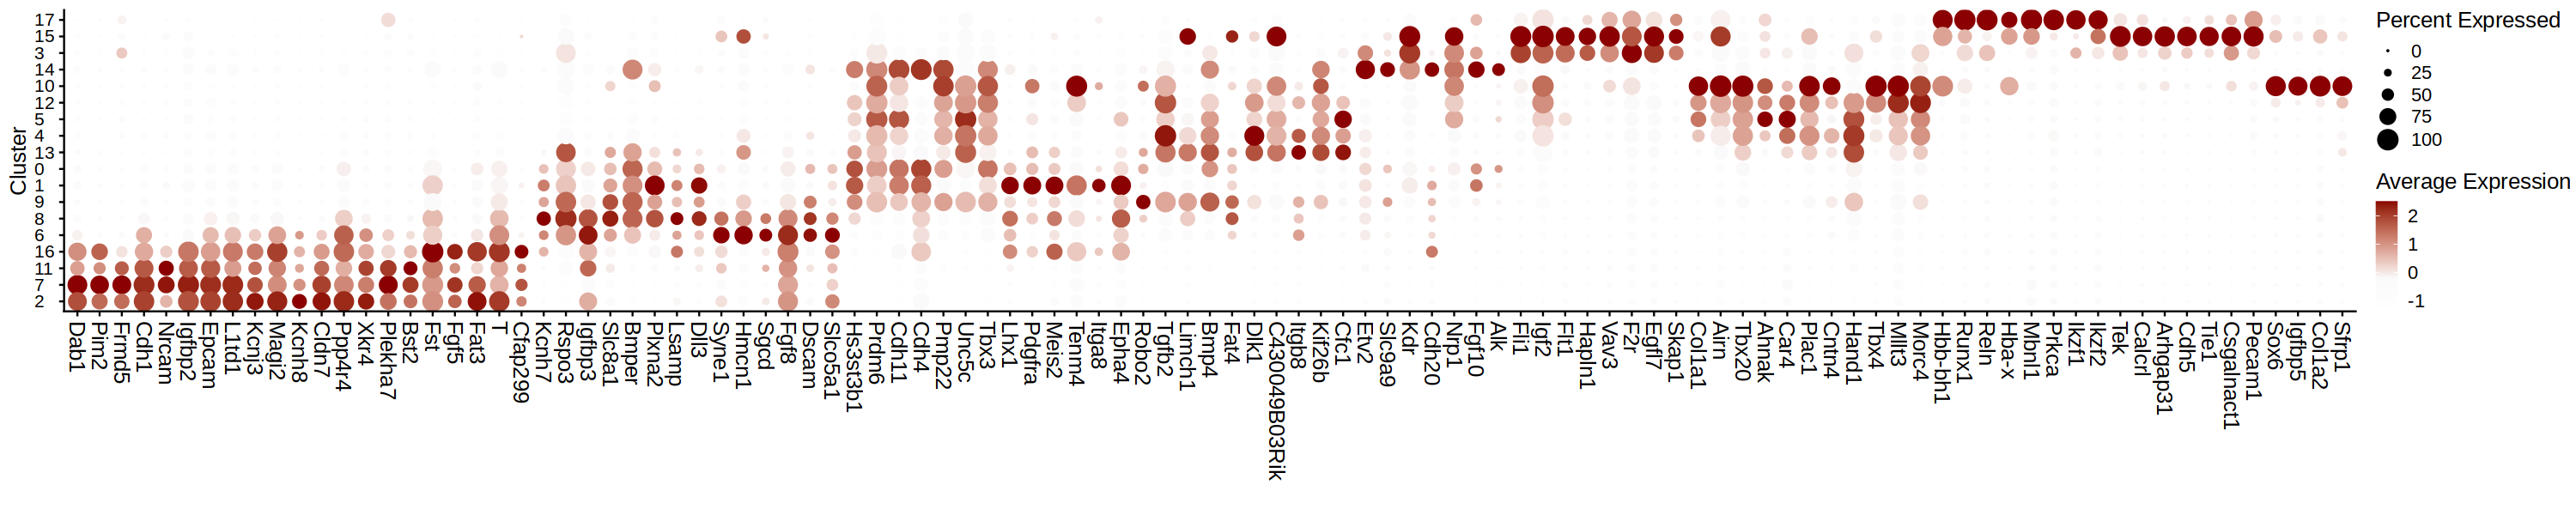

In [13]:
features = markers %>%
    group_by(cluster) %>%
    slice_max(n = 8, order_by = avg_log2FC) %>% .$gene


cluster_levels = c(2, 7, 11, 16, # Primitive_Streak
                  6, 8, 9, # Early_Mes_EOi
                  1, 0,  # Early_Mes_EOd
                  13, 4, # Posterior_Mes
                  5,  # Mesenchyme
                  12, # Allantois_Precursor
                  10, # Allantois
                  14, # HE_Precursor
                  3,  # HE
                  15, # Endothelium
                  17  # Blood_Progenitor
                  )

seurat@meta.data$mofa_cluster = factor(seurat@meta.data$mofa_cluster, levels = cluster_levels)

options(repr.plot.width=25, repr.plot.height=5)
DotPlot(seurat, features = unique(features), group.by = 'mofa_cluster') + 
    # scale_color_gradient(low='white', high='darkred', name='Average Expression') + 
    scale_color_gradientn(colours = c('white', 'grey98', 'darkred'), values = c(0, 0.3, 1)) + 
    RotatedAxis() +
    ylab('Cluster') + xlab('') +
    theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=15), 
                         axis.text.y=element_text(hjust=0))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


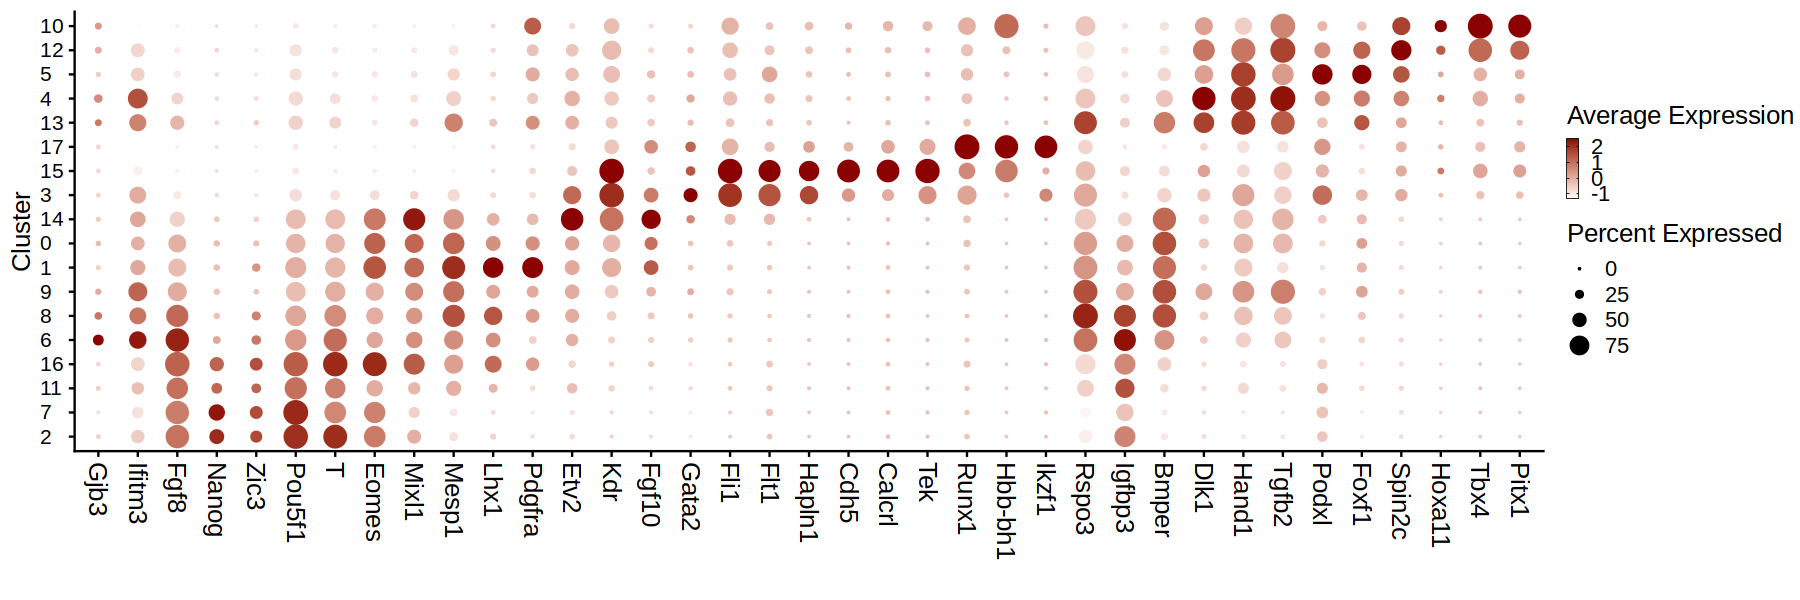

In [14]:
features = markers %>%
    group_by(cluster) %>%
    slice_max(n = 8, order_by = avg_log2FC) %>% .$gene

features = c('Gjb3', 'Ifitm3', 'Fgf8',  # PGC
             'Nanog', 'Zic3', 'Pou5f1', 'T', #PS
             'Eomes', 'Mixl1', 'Mesp1', 'Lhx1','Pdgfra',  #Early Mes 1
             'Etv2', 'Kdr', 'Fgf10', # HE Pre
             'Gata2', 'Fli1', 'Flt1', 'Hapln1', # HE
             'Cdh5', 'Calcrl', 'Tek', # Endo
             'Runx1', 'Hbb-bh1', 'Ikzf1', # Blood P
             'Rspo3', 'Igfbp3', 'Bmper', # Early Mes 2 --> search for other markers?
             'Dlk1', 'Hand1', 'Tgfb2',# Post Mes
             'Podxl', 'Foxf1', # Mesenchyme
             'Spin2c',
             'Hoxa11', 'Tbx4', 'Pitx1' # Allantois
             )

cluster_levels = c(2, 7, 11, 16,
                  6, 8, 
                  1, 0,  14,
                  9, 13, 
                  4, 5, 10, 12,
                  3, 15,
                  17)

cluster_levels = c(2, 7, 11, 16, # Primitive_Streak
                  6, 8, 9, # Early_Mes_EOi
                  1, 0,  # Early_Mes_EOd
                  14, # HE_Precursor
                  3,  # HE
                  15, # Endothelium
                  17,  # Blood_Progenitor
                  13, 4, # Posterior_Mes
                  5,  # Mesenchyme
                  12, # Allantois_Precursor
                  10  # Allantois
                  )

seurat@meta.data$mofa_cluster = factor(seurat@meta.data$mofa_cluster, levels = cluster_levels)

options(repr.plot.width=15, repr.plot.height=5)
DotPlot(seurat, features = unique(features), group.by = 'mofa_cluster') + 
    scale_color_gradient(low='white', high='darkred', name='Average Expression') + 
    #scale_color_gradientn(colours = c('white', 'white', 'darkred'), values = c(0, 0.3, 1)) + 
    RotatedAxis() +
    guides(colour = guide_colourbar(
         barwidth = 0.5, barheight = 2.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    ylab('Cluster') + xlab('') +
    theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=15), 
                         axis.text.y=element_text(hjust=0))

In [15]:
p2 = DotPlot(seurat, features = unique(features), group.by = 'mofa_cluster', scale = TRUE) + 
    scale_color_gradient(low='white', high='darkred', name = 'Average Expression') + 
    scale_size(range = c(-0.3, 1.5)) + 
    # scale_y_discrete(limits = names(opts$celltype_v2.colors2)) +
    scale_x_discrete(limits = features) +
    guides(colour = guide_colourbar(
         barwidth = 2.5, barheight = 0.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    geom_hline(yintercept=seq(.5, 20, 1), alpha=0.2, linewidth = 0.1) + 
    RotatedAxis() +
    ggtitle('Marker Gene Expression') + 
    theme(text=element_text(size=6), 
                         axis.text.x=element_text(angle=90,hjust=1,vjust=0.5, size=6), 
                         axis.text.y=element_text(hjust=1, size = 6),
                         axis.title = element_blank(),
                         panel.border = element_rect(color='black', linewidth=0.5),
                         plot.title = element_text(size=8, hjust=0.5, vjust=-1.5, face='plain'),
                         plot.margin = margin(0,0,0,0),
                         axis.line = element_blank(),
                         axis.ticks=element_line(linewidth=0.25),
                         legend.title = element_text(size = 7, hjust=0, vjust = 1),
                         legend.text = element_text(size = 6, hjust=0.5, vjust = 1),
                         legend.position = 'bottom')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


In [33]:
ggsave(file.path(args$outdir, 'cluster_marker_genes.pdf'), 
       plot = p2 + theme(legend.position = 'none'),
       width = 95, 
       height = 55, 
       units = "mm")

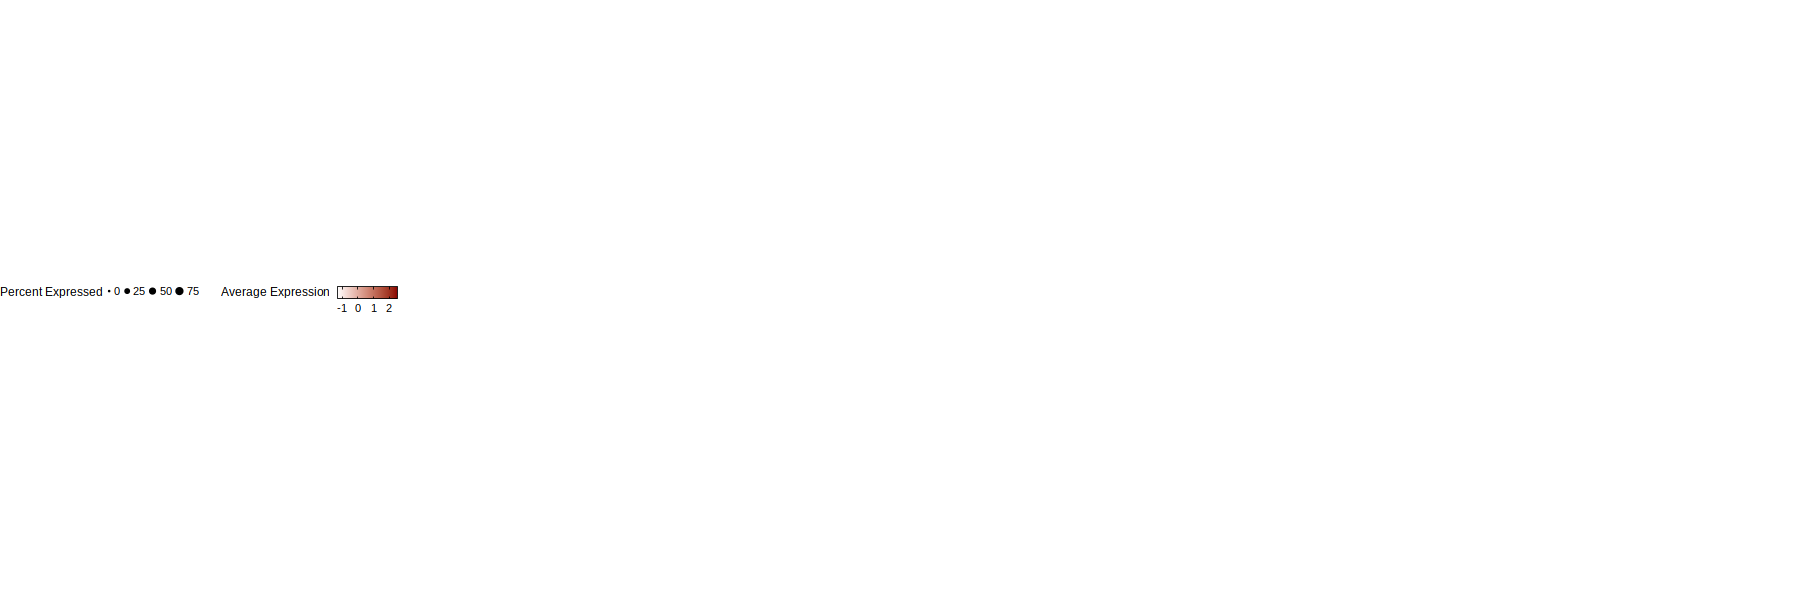

In [34]:
celltype_legend = as_ggplot(get_legend(p2 + theme(legend.key.size  = unit(0, "pt"),
                                                legend.margin=margin(0,0,0,0))))

celltype_legend
ggsave(file.path(args$outdir, 'cluster_marker_genes_legend.pdf'), 
       plot = celltype_legend,
       width = 90, 
       height = 8, 
       units = "mm")

In [17]:
# Violin plots instead of dotplot heatmap
seurat$celltype_v2_figure = opts$celltype_v2_figure[match(seurat$celltype_v2, names(opts$celltype_v2_figure))]

meta_tmp = as.data.table(seurat@meta.data, keep.rownames = T) %>% 
    .[,.(celltype_v2_figure)]

expr = mclapply(features, function(x){
    tmp = cbind(meta_tmp, 
                data.table(gene = x,
                           expression = as.numeric(logcounts(rna.sce[x,]))
                          )
               )
    return(tmp)
    
}, mc.cores = 32) %>% rbindlist() %>% 
    .[, expression_minmax := minmax.normalisation(expression), by = 'gene']

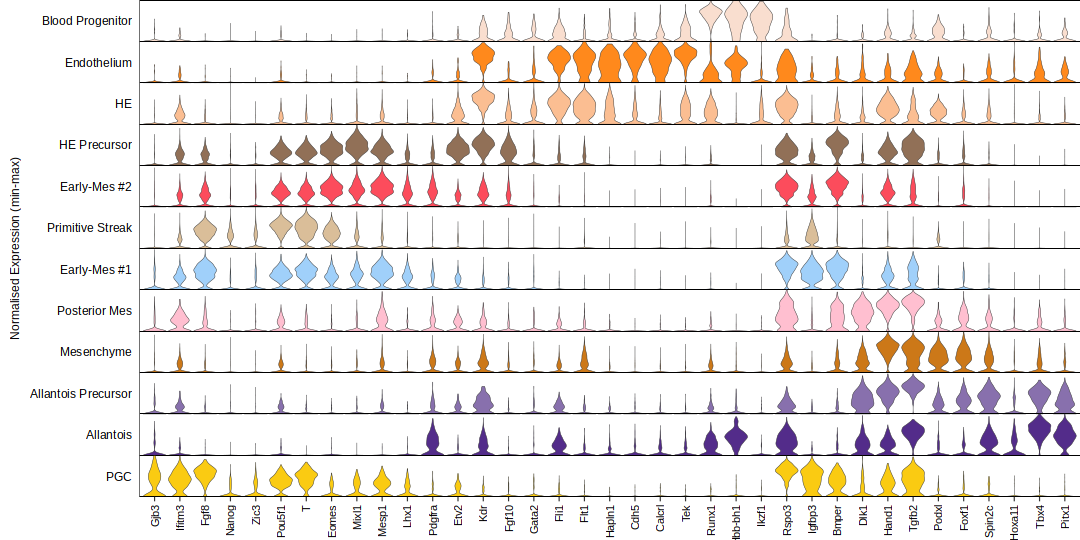

In [58]:
expr = expr %>%
    .[, gene := factor(gene, levels = features)] %>%
    .[, celltype_v2_figure := factor(celltype_v2_figure, levels = rev(names(opts$celltype_v2.colors2)))] %>%
    .[, expression_minmax_pruned := ifelse(expression_minmax > quantile(expression_minmax, 0.95), quantile(expression_minmax, 0.95),expression_minmax),
          by = c('celltype_v2_figure', 'gene')]
                                        
options(repr.plot.width=9, repr.plot.height=4.5)

p2 = ggplot(expr, aes(gene, expression_minmax, fill = celltype_v2_figure)) + 
    geom_violin(scale = 'width', linewidth = 0.1) +
    scale_fill_manual(values = opts$celltype_v2.colors2) + 
    scale_y_continuous(expand = c(0,0)) + 
    facet_grid(celltype_v2_figure~., switch = 'y') +
    ylab('Normalised Expression (min-max)') + 
    theme_bw() + 
    theme(axis.text.x = element_text(color = 'black',
                                     angle = 90, 
                                     hjust = 1,
                                     vjust = 0.5, size=6),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.title.x = element_blank(),
            strip.background = element_blank(),
            strip.text.y.left = element_text(angle = 0, hjust = 1, color= 'black', size=7),
            panel.spacing = unit(0,'lines'),
            panel.grid = element_blank(),
            legend.position = 'none',
            axis.title.y = element_text(size = 7, vjust = -2),
            panel.background = element_rect(color = "white", fill = NA, linewidth = 0.01),
            panel.border = element_rect(color = "black", fill = NA, linewidth = 0.2),
            plot.margin = margin(0,0,0,0),
            axis.line.y = element_blank(),
            axis.line.x = element_line(color = 'black', linewidth = 0.1),
            axis.ticks = element_line(linewidth=0.25),
)
p2

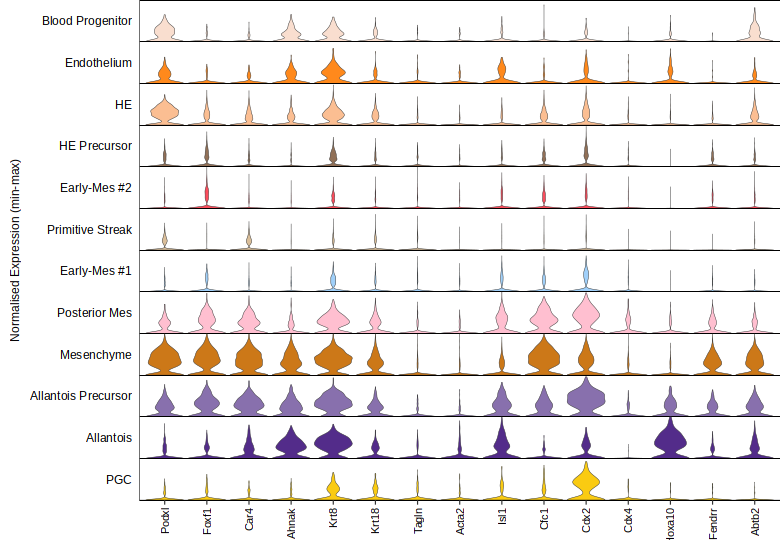

In [12]:
features = c(
             'Podxl', 'Foxf1', 'Car4', 'Ahnak', 'Krt8', 'Krt18', 'Tagln', 'Acta2', # Mesenchyme
             'Isl1', 'Cfc1', 'Cdx2', 'Cdx4', 'Hoxa10', 'Fendrr', 'Abtb2'
             )

# Violin plots instead of dotplot heatmap
seurat$celltype_v2_figure = opts$celltype_v2_figure[match(seurat$celltype_v2, names(opts$celltype_v2_figure))]

meta_tmp = as.data.table(seurat@meta.data, keep.rownames = T) %>% 
    .[,.(celltype_v2_figure)]

expr = mclapply(features, function(x){
    tmp = cbind(meta_tmp, 
                data.table(gene = x,
                           expression = as.numeric(logcounts(rna.sce[x,]))
                          )
               )
    return(tmp)
    
}, mc.cores = 32) %>% rbindlist() %>% 
    .[, expression_minmax := minmax.normalisation(expression), by = 'gene']

expr = expr %>%
    .[, gene := factor(gene, levels = features)] %>%
    .[, celltype_v2_figure := factor(celltype_v2_figure, levels = rev(names(opts$celltype_v2.colors2)))] %>%
    .[, expression_minmax_pruned := ifelse(expression_minmax > quantile(expression_minmax, 0.95), quantile(expression_minmax, 0.95),expression_minmax),
          by = c('celltype_v2_figure', 'gene')]
                                        
options(repr.plot.width=6.5, repr.plot.height=4.5)

p2 = ggplot(expr, aes(gene, expression_minmax, fill = celltype_v2_figure)) + 
    geom_violin(scale = 'width', linewidth = 0.1) +
    scale_fill_manual(values = opts$celltype_v2.colors2) + 
    scale_y_continuous(expand = c(0,0)) + 
    facet_grid(celltype_v2_figure~., switch = 'y') +
    ylab('Normalised Expression (min-max)') + 
    theme_bw() + 
    theme(axis.text.x = element_text(color = 'black',
                                     angle = 90, 
                                     hjust = 1,
                                     vjust = 0.5, size=6),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.title.x = element_blank(),
            strip.background = element_blank(),
            strip.text.y.left = element_text(angle = 0, hjust = 1, color= 'black', size=7),
            panel.spacing = unit(0,'lines'),
            panel.grid = element_blank(),
            legend.position = 'none',
            axis.title.y = element_text(size = 7, vjust = -2),
            panel.background = element_rect(color = "white", fill = NA, linewidth = 0.01),
            panel.border = element_rect(color = "black", fill = NA, linewidth = 0.2),
            plot.margin = margin(0,0,0,0),
            axis.line.y = element_blank(),
            axis.line.x = element_line(color = 'black', linewidth = 0.1),
            axis.ticks = element_line(linewidth=0.25),
)
p2

In [59]:
ggsave(file.path(args$outdir, 'celltype_marker_genes_violins.pdf'), 
       plot = p2,
       width = 105, 
       height = 55, 
       units = "mm")

In [11]:
# Violin plots instead of dotplot heatmap

features = c('Gjb3', 'Ifitm3', 'Fgf8',  # PGC
             'Nanog', 'Zic3', 'Pou5f1', 'T', #PS
             'Eomes', 'Mixl1', 'Mesp1', 'Lhx1','Pdgfra',  #Early Mes 1
             'Etv2', 'Kdr', 'Fgf10', # HE Pre
             'Gata2', 'Fli1', 'Flt1', 'Hapln1', # HE
             'Cdh5', 'Calcrl', 'Tek', # Endo
             'Runx1', 'Hbb-bh1', 'Ikzf1', # Blood P
             'Rspo3', 'Igfbp3', 'Bmper', # Early Mes 2 --> search for other markers?
             'Dlk1', 'Hand1', 'Tgfb2',# Post Mes
             'Podxl', 'Foxf1', # Mesenchyme
             'Spin2c',
             'Hoxa11', 'Tbx4', 'Pitx1' # Allantois
             )

cluster_levels = c(2, 7, 11, 16,
                  6, 8, 
                  1, 0,  14,
                  9, 13, 
                  4, 5, 10, 12,
                  3, 15,
                  17)

cluster_levels = c(
                  17,  # Blood_Progenitor
                  15, # Endothelium
                  3,  # HE
                  14, # HE_Precursor
                  1, 0,  # Early_Mes_EOd
                  2, 7, 11, 16, # Primitive_Streak
                  6, 8, 9, # Early_Mes_EOi
                  13, 4, # Posterior_Mes
                  5,  # Mesenchyme
                  12, # Allantois_Precursor
                  10  # Allantois
                  )

meta_tmp = as.data.table(seurat@meta.data, keep.rownames = T) %>% 
    .[,.(mofa_cluster)]

expr = mclapply(features, function(x){
    tmp = cbind(meta_tmp, 
                data.table(gene = x,
                           expression = as.numeric(logcounts(rna.sce[x,]))
                          )
               )
    return(tmp)
    
}, mc.cores = 32) %>% rbindlist() %>% 
    .[, expression_minmax := minmax.normalisation(expression), by = 'gene']

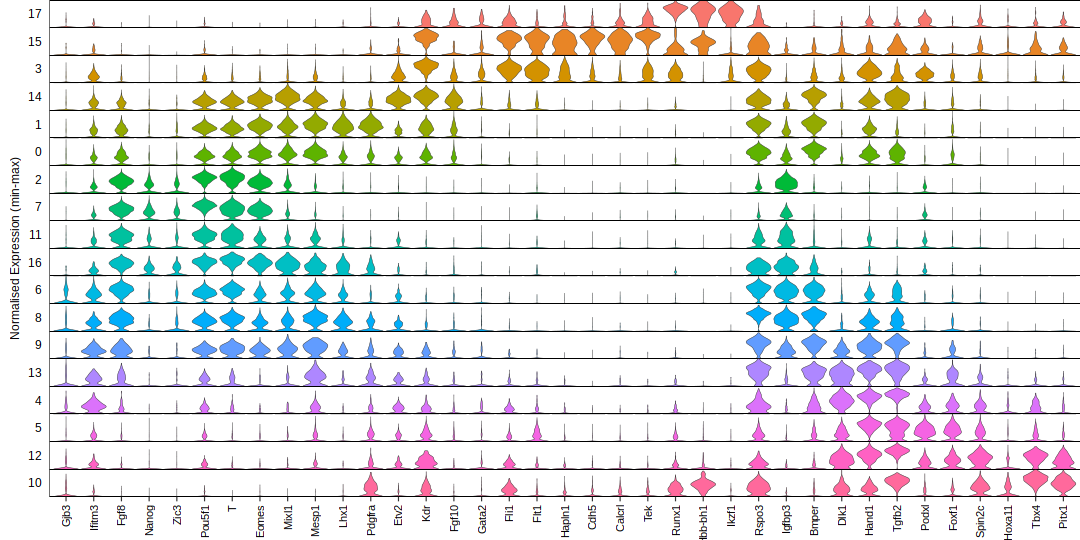

In [13]:
expr = expr %>%
    .[, gene := factor(gene, levels = features)] %>%
    .[, mofa_cluster := factor(mofa_cluster, levels = cluster_levels)] %>%
    .[, expression_minmax_pruned := ifelse(expression_minmax > quantile(expression_minmax, 0.95), quantile(expression_minmax, 0.95),expression_minmax),
          by = c('mofa_cluster', 'gene')]
                                        
options(repr.plot.width=9, repr.plot.height=4.5)

p3 = ggplot(expr, aes(gene, expression_minmax, fill = mofa_cluster)) + 
    geom_violin(scale = 'width', linewidth = 0.1) +
    scale_y_continuous(expand = c(0,0)) + 
    facet_grid(mofa_cluster~., switch = 'y') +
    ylab('Normalised Expression (min-max)') + 
    theme_bw() + 
    theme(axis.text.x = element_text(color = 'black',
                                     angle = 90, 
                                     hjust = 1,
                                     vjust = 0.5, size=6),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.title.x = element_blank(),
            strip.background = element_blank(),
            strip.text.y.left = element_text(angle = 0, hjust = 1, color= 'black', size=7),
            panel.spacing = unit(0,'lines'),
            panel.grid = element_blank(),
            legend.position = 'none',
            axis.title.y = element_text(size = 7, vjust = -2),
            panel.background = element_rect(color = "white", fill = NA, linewidth = 0.01),
            panel.border = element_rect(color = "black", fill = NA, linewidth = 0.2),
            plot.margin = margin(0,0,0,0),
            axis.line.y = element_blank(),
            axis.line.x = element_line(color = 'black', linewidth = 0.1),
            axis.ticks = element_line(linewidth=0.25),
)
p3

In [14]:
ggsave(file.path(args$outdir, 'cluster_marker_genes_violins.pdf'), 
       plot = p3,
       width = 95, 
       height = 55, 
       units = "mm")

## ATAC markers

In [24]:
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')
ArchRProject <- loadArchRProject(args$archr_directory)[meta$cell]
ArchRProject = ArchRProject[meta$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [25]:
addArchRThreads(22)

Setting default number of Parallel threads to 22.



In [26]:
ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.numeric(meta$mofa_cluster),
                                    cells = meta$cell,
                                    name = "mofa_cluster",
                                    force=TRUE)

In [27]:
# markersPeaks <- getMarkerFeatures(
#     ArchRProj = ArchRProject, 
#     useMatrix = "PeakMatrix", 
#     groupBy = "mofa_cluster",
#     bias = c("TSSEnrichment", "log10(nFrags)"),
#     testMethod = "wilcoxon"
# )

# io$multiome = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/'
# cisbp_silico_chip = readRDS(file.path(io$multiome, 'vitro_peaks_silicoChIP_cisbp.rds'))
# assay(cisbp_silico_chip, 'matches') = assay(cisbp_silico_chip, 'VirtualChipScores') > 0.20
# assay(cisbp_silico_chip, 'motifScores') = NULL
# assay(cisbp_silico_chip, 'motifMatches') = NULL
# assay(cisbp_silico_chip, 'motifCounts') = NULL
# assay(cisbp_silico_chip, 'VirtualChipScores') = NULL
# # Keep only motifs with more than 40 peaks 
# tmp = colSums(assay(cisbp_silico_chip, 'matches') )
# keep = names(tmp[tmp > 40])
# cisbp_silico_chip = cisbp_silico_chip[,keep]

# plot_enr_heatmap = function(enrichMotifs, ntop=25, TFs = NULL) {
#     heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)
#     rownames(heatmapEM) = str_split(rownames(heatmapEM), ' ') %>% map_chr(1)
    
#     enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
#         .[order(-value)] %>% .[,TF:=strsplit(TF, '_') %>% map_chr(1)]

#     if(!is.null(TFs)){
#         keep_tfs = TFs
#     }else{
#         keep_tfs = enriched.dt %>% .[,variable:=factor(variable, levels= cluster_levels)] %>% .[order(variable)] %>% .[, head(.SD, ntop),  by=variable] %>% .$TF   
#     }
    
#     enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
#         #.[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
#          .[,TF:=factor(TF, levels=unique(keep_tfs))] %>%
#        #  .[,variable := opts$celltype_v2_figure[match(variable, names(opts$celltype_v2_figure))]] %>% 
#          .[,variable := factor(variable, levels=cluster_levels)]

#     p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
#         geom_tile() +
#         scale_fill_gradient(low='white', high='darkblue', name='-log10(FDR)', breaks = c(0,100), labels = c('Min', 'Max')) +
#         guides(fill = guide_colourbar(
#             barwidth = 0.5, barheight = 2.5,
#             frame.colour = "black", 
#             ticks.colour = "black"
#         )) + 
#       #  scale_y_discrete(limits = names(opts$celltype_v2.colors2)) +
#         scale_x_discrete(limits = unique(keep_tfs), expand = c(0,0,0,0)) +
#         geom_hline(yintercept=seq(.5, 20, 1), alpha=0.2, linewidth = 0.1) + 
#         geom_hline(yintercept=c(6.5, 7.5), alpha=1, linewidth = 0.1) + 
#         ggtitle('Motifs in marker peaks') + 
#         theme(text=element_text(size=6), 
#                          axis.text.x=element_text(angle=90,hjust=1,vjust=0.5, size=6, color = 'black'), 
#                          # axis.text.y=element_blank(),
#                          axis.text.y=element_text(hjust=1, size = 6, color = 'black'),
#                          axis.title = element_blank(),
#                          panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
#                          panel.background = element_blank(),
#                          plot.margin = margin(0,0,0,0),
#                          plot.title = element_text(size=8, hjust=0.5, vjust=-1.5, face='plain'),
#                          axis.line = element_blank(),
#                          axis.ticks=element_line(linewidth=0.25),
#                          legend.title = element_text(size = 7, hjust=0, vjust = 1),
#                          legend.text = element_text(size = 6, hjust=0.5, vjust = 1),
#                          legend.position = 'right')
#     return(p)
# }

# TFs_plot = c('TFAP2C', # Add TFAP2C once updated chromvar is done!
#              'NANOG', 'ZIC3','POU5F1',
#              'T', 'EOMES', 'MIXL1', 
#              'MESP2', 'LHX1','SNAI1', 'LEF1', 
#              'ETV2', 'GATA2', 
#              'SOX7', 'ERG', 'SOX18', 
#              'RUNX1', 'TAL1', 'GATA1', 
#              'TCF7L1', 
#              'HAND1', 'GATA5', 'FOXF2',
#              'CDX4', 'HOXA11', 'TBX4',  'PITX1'
#              )

# enrichMotifs <- suppressMessages(peakAnnoEnrichment(
#     seMarker = markersPeaks,
#     ArchRProj = ArchRProject,
#     #peakAnnotation = "silicoChIP_CISBP",
#     matches = cisbp_silico_chip,
#     cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
#   ))

# p3 = plot_enr_heatmap(enrichMotifs, TFs = TFs_plot, ntop=10000)
# p3

In [28]:
# Differential ChromVAR one v all
diffMotif <- getMarkerFeatures(
    ArchRProj = ArchRProject, 
    testMethod = "wilcoxon",
    binarize = FALSE,
   # useMatrix = "silicoChIP_CISBPMatrix",
    useMatrix = "silicoChIP_CISBP_v2", # "silicoChIP_CISBPMatrix", # this is the v2 in silico ChIP for CISBP
   # maxCells = 1e10, # Use all cells
    groupBy = "mofa_cluster",
    useSeqnames="z",
    verbose = F
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-2faad272b40f96-Date-2024-11-18_Time-14-46-49.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Assays.Matrix

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-2faad272b40f96-Date-2024-11-18_Time-14-46-49.log



In [29]:
diffMotif.dt = lapply(colnames(diffMotif), function(x){
    tmp = data.table(motif = str_split(rowData(diffMotif)$name, '_') %>% map_chr(1),
                                  FDR = assay(diffMotif[,x], 'FDR')[[1]],
                                  MeanDiff = assay(diffMotif[,x], 'MeanDiff')[[1]]) %>% 
                        .[order(-MeanDiff)] %>% 
                        .[,mofa_cluster := as.factor(x)]
    return(tmp)
}) %>% rbindlist()

In [30]:
silicoCISBP.mtx = getMatrixFromProject(ArchRProject, 'silicoChIP_CISBP_v2')

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-2faad26fc1be07-Date-2024-11-18_Time-14-47-10.log
If there is an issue, please report to github with logFile!

2024-11-18 14:47:22 : Organizing colData, 0.198 mins elapsed.

2024-11-18 14:47:22 : Organizing rowData, 0.208 mins elapsed.

2024-11-18 14:47:22 : Organizing rowRanges, 0.208 mins elapsed.

2024-11-18 14:47:22 : Organizing Assays (1 of 2), 0.208 mins elapsed.

2024-11-18 14:47:23 : Organizing Assays (2 of 2), 0.217 mins elapsed.

2024-11-18 14:47:23 : Constructing SummarizedExperiment, 0.229 mins elapsed.

2024-11-18 14:47:25 : Finished Matrix Creation, 0.262 mins elapsed.



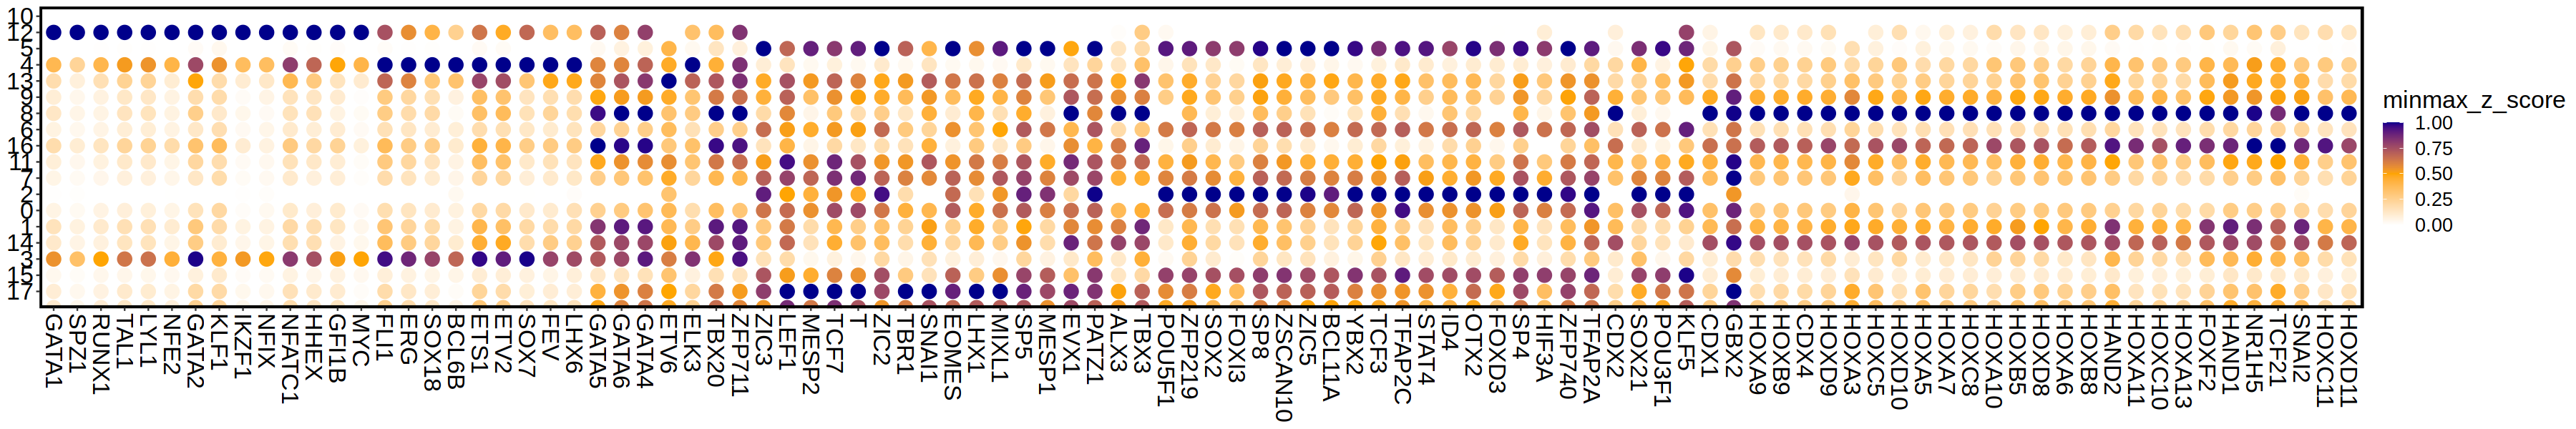

In [31]:
features = diffMotif.dt[MeanDiff>0] %>% 
                .[, mofa_cluster := factor(mofa_cluster, levels = cluster_levels)] %>% 
                .[order(mofa_cluster, -MeanDiff)] %>% 
                .[,head(.SD, 15), by=mofa_cluster] %>% .$motif %>% unique()

features = features[features %in% rownames(silicoCISBP.mtx)]

tmp = silicoCISBP.mtx[features,]
celltype_chromVAR.dt = lapply(unique(meta$mofa_cluster), function(x){
    tmp2 = data.table(mofa_cluster = x,
                      feature = rownames(tmp),
                      z_score = rowMeans(tmp@assays@data$z[,meta[mofa_cluster == x, cell]])
                      )
    return(tmp2)
}) %>% rbindlist() %>% 
    .[,minmax_z_score := minmax.normalisation(z_score), by='feature'] %>% 
    setnames('feature', 'motif')

options(repr.plot.width=30, repr.plot.height=5)
ggplot(celltype_chromVAR.dt, aes(motif, mofa_cluster, color=minmax_z_score)) + 
    geom_point(size = 5) +
    scale_color_gradientn(colors = c('white', 'orange', 'darkblue')) +
   # scale_color_gradientn(colors = rainbow(n=2)) +
    scale_y_discrete(limits = as.factor(cluster_levels)) +
    scale_x_discrete(limits = features) +
  #  theme_bw() + 
    theme(text=element_text(size=20), 
                         axis.text = element_text(color='black'),
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=20), 
                         axis.text.y=element_text(hjust=1, size = 20),
                         axis.title = element_blank(),
                         panel.border = element_rect(color='black', linewidth=1.5, fill=NA),
                         panel.background = element_blank(),
                         axis.line = element_blank())

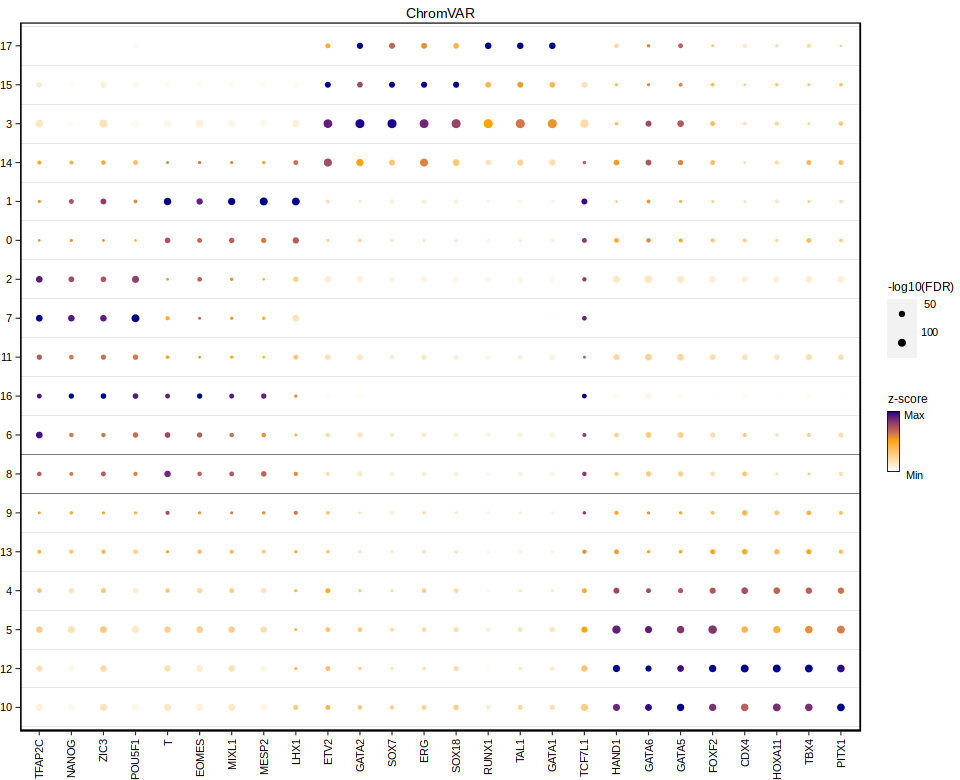

In [34]:
features = c('TFAP2C', # Add TFAP2C once updated chromvar is done!
             'NANOG', 'ZIC3','POU5F1',
             'T', 'EOMES', 'MIXL1',  
             'MESP2', 'LHX1',  
             'ETV2', 'GATA2', 
             'SOX7', 'ERG', 'SOX18', 
             'RUNX1', 'TAL1', 'GATA1', 
             'TCF7L1', 
             'HAND1', 'GATA6', 'GATA5', 'FOXF2',
             'CDX4', 'HOXA11', 'TBX4',  'PITX1'
             )

tmp = silicoCISBP.mtx[features,]
celltype_chromVAR.dt = lapply(unique(meta$mofa_cluster), function(x){
    tmp2 = data.table(mofa_cluster = as.factor(x),
                      feature = rownames(tmp),
                      z_score = rowMeans(tmp@assays@data$z[,meta[mofa_cluster == x, cell]])
                      )
    return(tmp2)
}) %>% rbindlist() %>% 
    .[,minmax_z_score := minmax.normalisation(z_score), by='feature'] %>% 
    setnames('feature', 'motif')


tmp = merge(diffMotif.dt, celltype_chromVAR.dt , by=c('mofa_cluster', 'motif')) %>%
    .[, mofa_cluster := factor(mofa_cluster, levels = rev(cluster_levels))]
# tmp$celltype_v2_figure = opts$celltype_v2_figure[match(tmp$mofa_cluster, cluster_lev)]

options(repr.plot.width=8, repr.plot.height=6.5)
p3 = ggplot(tmp, aes(motif, mofa_cluster, color=minmax_z_score, size = -log10(FDR))) + 
    geom_point() +
    scale_color_gradientn(colors = c('white', 'orange', 'darkblue'), name = 'z-score', breaks = c(0,1), labels = c('Min', 'Max')) +
    guides(colour = guide_colourbar(
         barwidth = 0.5, barheight = 2.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    scale_size(range = c(-0.3, 1.5)) + 
    # scale_y_discrete(limits = names(opts$celltype_v2.colors2)) +
    scale_x_discrete(limits = features) +
    geom_hline(yintercept=seq(.5, 20, 1), alpha=0.2, linewidth = 0.1) + 
    geom_hline(yintercept=c(6.5, 7.5), alpha=1, linewidth = 0.1) + 
    ggtitle('ChromVAR') +

    theme(text=element_text(size=6), 
                         axis.text.x=element_text(angle=90,hjust=1,vjust=0.5, size=6, color = 'black'), 
                         axis.text.y=element_text(hjust=1, size = 6, color = 'black'),
                         axis.title = element_blank(),
                         panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
                         panel.background = element_blank(),
                         plot.margin = margin(0,0,0,0),
                         plot.title = element_text(size=8, hjust=0.5, vjust=-1.5, face='plain'),
                         axis.line = element_blank(),
                         axis.ticks=element_line(linewidth=0.25),
                         legend.title = element_text(size = 7, hjust=0, vjust = 1),
                         legend.text = element_text(size = 6, hjust=0.5, vjust = 1),
                         legend.position = 'right',
                        # plot.margin = margin(t = 0, r = 0, b = 0, l = 0) # Adjust margins as needed
)

p3

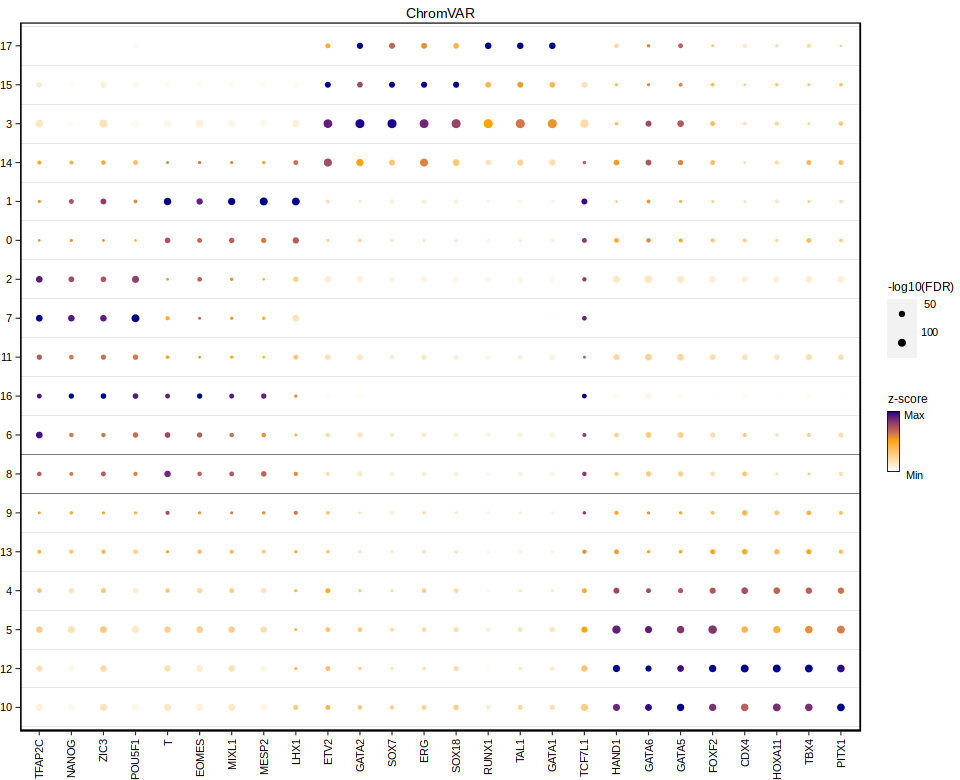

In [34]:
features = c('TFAP2C', # Add TFAP2C once updated chromvar is done!
             'NANOG', 'ZIC3','POU5F1',
             'T', 'EOMES', 'MIXL1',  
             'MESP2', 'LHX1',  
             'ETV2', 'GATA2', 
             'SOX7', 'ERG', 'SOX18', 
             'RUNX1', 'TAL1', 'GATA1', 
             'TCF7L1', 
             'HAND1', 'GATA6', 'GATA5', 'FOXF2',
             'CDX4', 'HOXA11', 'TBX4',  'PITX1'
             )

tmp = silicoCISBP.mtx[features,]
celltype_chromVAR.dt = lapply(unique(meta$mofa_cluster), function(x){
    tmp2 = data.table(mofa_cluster = as.factor(x),
                      feature = rownames(tmp),
                      z_score = rowMeans(tmp@assays@data$z[,meta[mofa_cluster == x, cell]])
                      )
    return(tmp2)
}) %>% rbindlist() %>% 
    .[,minmax_z_score := minmax.normalisation(z_score), by='feature'] %>% 
    setnames('feature', 'motif')


tmp = merge(diffMotif.dt, celltype_chromVAR.dt , by=c('mofa_cluster', 'motif')) %>%
    .[, mofa_cluster := factor(mofa_cluster, levels = rev(cluster_levels))]
# tmp$celltype_v2_figure = opts$celltype_v2_figure[match(tmp$mofa_cluster, cluster_lev)]

options(repr.plot.width=8, repr.plot.height=6.5)
p3 = ggplot(tmp, aes(motif, mofa_cluster, color=minmax_z_score, size = -log10(FDR))) + 
    geom_point() +
    scale_color_gradientn(colors = c('white', 'orange', 'darkblue'), name = 'z-score', breaks = c(0,1), labels = c('Min', 'Max')) +
    guides(colour = guide_colourbar(
         barwidth = 0.5, barheight = 2.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    scale_size(range = c(-0.3, 1.5)) + 
    # scale_y_discrete(limits = names(opts$celltype_v2.colors2)) +
    scale_x_discrete(limits = features) +
    geom_hline(yintercept=seq(.5, 20, 1), alpha=0.2, linewidth = 0.1) + 
    geom_hline(yintercept=c(6.5, 7.5), alpha=1, linewidth = 0.1) + 
    ggtitle('ChromVAR') +

    theme(text=element_text(size=6), 
                         axis.text.x=element_text(angle=90,hjust=1,vjust=0.5, size=6, color = 'black'), 
                         axis.text.y=element_text(hjust=1, size = 6, color = 'black'),
                         axis.title = element_blank(),
                         panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
                         panel.background = element_blank(),
                         plot.margin = margin(0,0,0,0),
                         plot.title = element_text(size=8, hjust=0.5, vjust=-1.5, face='plain'),
                         axis.line = element_blank(),
                         axis.ticks=element_line(linewidth=0.25),
                         legend.title = element_text(size = 7, hjust=0, vjust = 1),
                         legend.text = element_text(size = 6, hjust=0.5, vjust = 1),
                         legend.position = 'right',
                        # plot.margin = margin(t = 0, r = 0, b = 0, l = 0) # Adjust margins as needed
)

p3

In [35]:
ggsave(file.path(args$outdir, 'cluster_marker_chromvar.pdf'), 
       plot = p3 + theme(legend.position = 'none'),
       width = 80, 
       height = 55, 
       units = "mm")

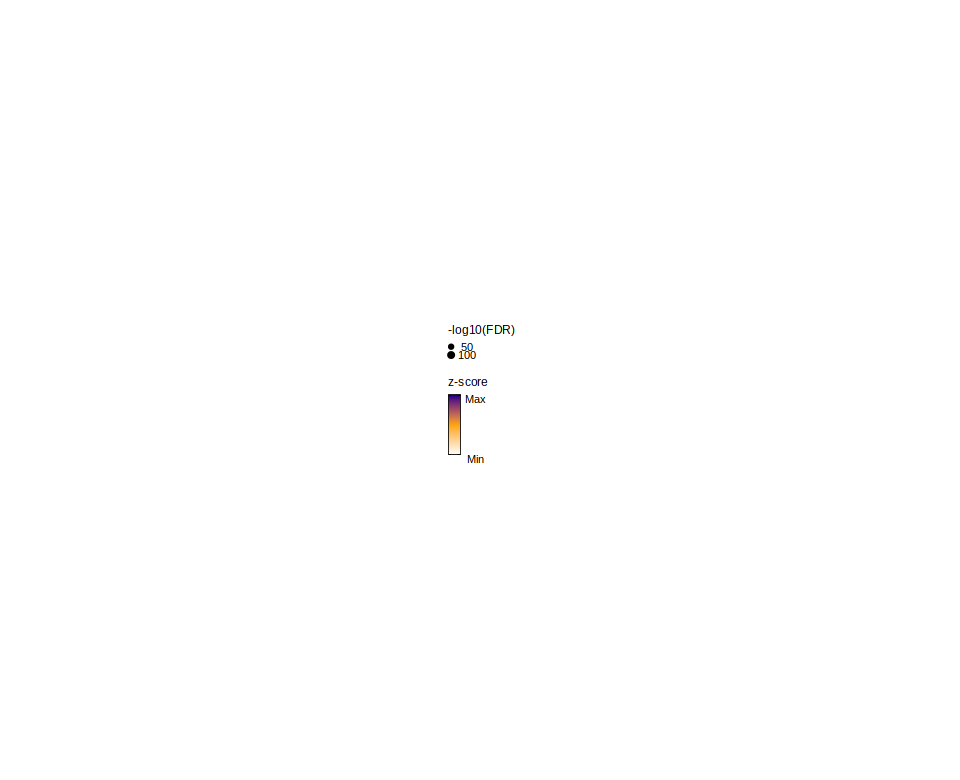

In [50]:
celltype_legend = as_ggplot(get_legend(p3 + theme(legend.key.size  = unit(0, "pt"),
                                                legend.margin=margin(0,0,0,0),
                                                 legend.key = element_blank())))

celltype_legend
ggsave(file.path(args$outdir, 'cluster_marker_chromvar_legend.pdf'), 
       plot = celltype_legend,
       width = 20, 
       height = 90, 
       units = "mm")